# 1. Problem Formulation

We are predicting **sepsis onset hour-by-hour** for ICU patients, using a **Bayesian Network**, with the
goal of flagging risk earlier than it would typically be clinically documented (the dataset's `SepsisLabel`
is set 6 hours before clinical suspicion is recorded, so an accurate hourly prediction is inherently an
early-warning signal).

- **Task type**: binary classification (sepsis / no sepsis), predicted separately for every hour of every patient's stay.
- **Evaluation metrics**: precision, recall, F1-score, confusion matrix, ROC-AUC, PR-AUC, log-loss, Brier score, and a calibration curve — chosen because sepsis is rare (~2% of hourly records), so accuracy alone would be misleading.
- **Success criteria**: AUROC ≥ 0.75 with clinically meaningful sensitivity at 85% specificity.

# 2. Data Collection / Loading & Cleaning

### Install the Kaggle CLI
Installs the `kaggle` package so we can download the dataset directly into this environment.

In [1]:
!pip install kaggle

Defaulting to user installation because normal site-packages is not writeable


### Authenticate with Kaggle
Saves the Kaggle API token so the CLI can download data on our behalf.

In [2]:
# This will create a link between the Notebook and the Kaggle website page with the dataset
!mkdir -p ~/.kaggle && echo KGAT_d31f7ba50050e2a02da379837da3bbff > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

### Verify authentication
Confirms the token works by listing competitions — if this errors, the token step above needs redoing.

In [3]:
!python -m kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

### Download the dataset
Downloads and unzips the full PhysioNet/CinC 2019 sepsis dataset (training set A) directly into this environment, avoiding the unreliable browser-upload route.

In [4]:
!python -m kaggle datasets download -d salikhussaini49/prediction-of-sepsis -p ./kaggle_download --unzip

Dataset URL: https://www.kaggle.com/datasets/salikhussaini49/prediction-of-sepsis
License(s): CC-BY-NC-SA-4.0
100%|██████████████████████████████████████| 74.7M/74.7M [00:01<00:00, 39.8MB/s]



### Inspect the downloaded folder structure
Walks the downloaded folder and prints how many files sit in each subfolder, so we can confirm the full dataset (20,336 patient files) arrived before loading anything.

In [5]:
import os
for root, dirs, files in os.walk("./kaggle_download"):
    if files:
        print(root, "->", len(files), "files")

./kaggle_download -> 6 files
./kaggle_download/training_setB/training_setB -> 20000 files
./kaggle_download/training_setA/training -> 20336 files


### Load every patient file into one table
Each patient is stored as a separate pipe-delimited (.psv) file, one row per ICU hour. This reads every file, tags each with a PatientID, and concatenates them into a single DataFrame (`raw`).

In [6]:
data_dir = "./kaggle_download/training_setA/training"

from pathlib import Path
import pandas as pd

def read_psv(path, patient_id):
    df = pd.read_csv(path, sep="|")
    df["PatientID"] = patient_id
    return df

def load_all_patients(data_dir):
    data_dir = Path(data_dir)
    frames = []
    for f in sorted(data_dir.glob("*.psv")):
        frames.append(read_psv(f, f.stem))
    if not frames:
        raise FileNotFoundError("No .psv files found — check DATA_DIR.")
    return pd.concat(frames, ignore_index=True)

raw = load_all_patients(data_dir)
print(raw.shape)
print(raw["PatientID"].nunique(), "patients")

(790215, 42)
20336 patients


### Initial inspection
Checks missingness per column and the sepsis-positive rate at both the row (hourly) and patient level, before any cleaning decisions are made.

In [7]:
n_patients = raw["PatientID"].nunique()
print(f"Rows (hours): {len(raw)}")
print(f"Patients: {n_patients}")
print(f"Columns: {list(raw.columns)}")

missing_pct = raw.isna().mean().sort_values(ascending=False) * 100
print("\nMissingness by column (%):")
print(missing_pct.round(1))

row_rate = raw["SepsisLabel"].mean()
patient_rate = raw.groupby("PatientID")["SepsisLabel"].max().mean()
print(f"Row-level positive rate: {row_rate:.3%}")
print(f"Patient-level positive rate: {patient_rate:.3%}")

Rows (hours): 790215
Patients: 20336
Columns: ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'PatientID']

Missingness by column (%):
EtCO2               100.0
TroponinI            99.9
Bilirubin_direct     99.9
Fibrinogen           99.2
Bilirubin_total      98.8
Alkalinephos         98.5
AST                  98.5
Lactate              96.6
PTT                  95.2
SaO2                 95.0
Calcium              95.0
Phosphate            95.0
Platelets            93.5
Creatinine           93.4
WBC                  92.5
Magnesium            92.2
HCO3                 91.9
BUN                  91.8
Chloride            

### Clean the data (Leakage-Free)
Removes duplicate rows, resets physiologically implausible vital-sign values to missing, and forward-fills within each patient — deliberately dropping back-fill, since pulling a future reading backward in time would let a clinically unavailable value leak into an earlier hour, undermining the hourly early-warning framing. EtCO2 is dropped (100% missing, nothing to impute). Population-median imputation is intentionally not done here — it's deferred to after the train/val/test split, so it can be calculated from training data only.

In [8]:
import numpy as np

# --- 1. Remove exact duplicate rows -----------------------------
before = len(raw)
df = raw.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows")

# --- 2. Catch physiologically impossible values (data-entry errors) ---------
plausible_ranges = {
    "HR": (20, 300), "O2Sat": (50, 100), "Temp": (25, 45),
    "SBP": (40, 300), "MAP": (20, 250), "DBP": (10, 200),
    "Resp": (4, 60), "Age": (0, 120),
}
for col, (lo, hi) in plausible_ranges.items():
    if col in df.columns:
        bad = ~df[col].between(lo, hi) & df[col].notna()
        print(f"{col}: {bad.sum()} implausible values set to NaN")
        df.loc[bad, col] = np.nan

# --- 3. Forward-fill ONLY, within each patient -----------------------
df = df.sort_values(["PatientID", "ICULOS"]) if "ICULOS" in df.columns else df.sort_values("PatientID")
value_cols = [c for c in df.columns if c not in ("PatientID", "SepsisLabel")]
df[value_cols] = df.groupby("PatientID")[value_cols].transform(lambda s: s.ffill())

# --- 4. Drop EtCO2 — 100% missing, nothing to impute from ----------------
if "EtCO2" in df.columns and df["EtCO2"].isna().all():
    print("Dropping EtCO2 — 100% missing")
    df = df.drop(columns=["EtCO2"])

print(f"\nShape after leakage-free cleaning: {df.shape}")
print(f"Remaining missing values (filled after split): {df.isna().sum().sum():,}")

Dropped 0 duplicate rows
HR: 0 implausible values set to NaN
O2Sat: 176 implausible values set to NaN
Temp: 4 implausible values set to NaN
SBP: 59 implausible values set to NaN
MAP: 94 implausible values set to NaN
DBP: 13 implausible values set to NaN
Resp: 224 implausible values set to NaN
Age: 0 implausible values set to NaN
Dropping EtCO2 — 100% missing

Shape after leakage-free cleaning: (790215, 41)
Remaining missing values (filled after split): 9,804,678


# 3. Get to Know Your Data (EDA)

**A note on ordering:** the ML process slides recommend splitting the data *before* deep EDA or feature
engineering, to avoid any risk of decisions being informed by data the model will later be tested on. The
EDA and feature engineering below are deliberately kept *before* the split for this project, because they
are purely descriptive/derived from each patient's own history (no cross-patient or outcome-driven feature
selection happens here) — nothing here picks features based on looking at labels across the whole dataset.
The actual leakage-sensitive steps (discretization bin edges, and the Bayesian Network itself) are correctly
fit on the training split only, further down.

### Descriptive statistics
Computes mean, median, standard deviation, quartiles, and skew for every clinical variable — establishing each variable's shape before we look at its relationship to sepsis.

In [9]:
clinical_vars = [c for c in df.columns if c not in ("PatientID", "SepsisLabel", "Gender", "Unit1", "Unit2", "HospAdmTime", "ICULOS")]

desc_stats = df[clinical_vars].describe().T
desc_stats["median"] = df[clinical_vars].median()
desc_stats["skew"] = df[clinical_vars].skew()
desc_stats = desc_stats[["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max", "skew"]]
print(desc_stats.round(2))

                     count    mean  median     std    min     25%     50%  \
HR                776615.0   84.89   84.00   17.01  20.00   73.00   84.00   
O2Sat             774814.0   97.22   98.00    2.96  50.00   96.00   98.00   
Temp              732953.0   36.94   36.94    0.74  26.60   36.45   36.94   
SBP               753312.0  120.87  119.00   21.65  40.00  105.00  119.00   
MAP               775899.0   78.85   77.00   14.93  20.00   68.33   77.00   
DBP               493145.0   60.61   59.00   13.26  20.00   52.00   59.00   
Resp              774042.0   18.79   18.00    5.38   4.00   15.00   18.00   
BaseExcess        473507.0   -0.02    0.00    4.00 -32.00   -2.00    0.00   
HCO3              659132.0   24.38   24.00    4.21   0.00   22.00   24.00   
FiO2              456981.0    0.50    0.50    0.19   0.00    0.40    0.50   
pH                488821.0    7.39    7.40    0.06   6.62    7.36    7.40   
PaCO2             468754.0   40.83   40.00    8.31  10.00   36.00   40.00   

### Patient-level sepsis distribution
Bar chart of how many patients ever developed sepsis vs. never did, with counts and percentages labelled — shows the class imbalance we need to account for later.

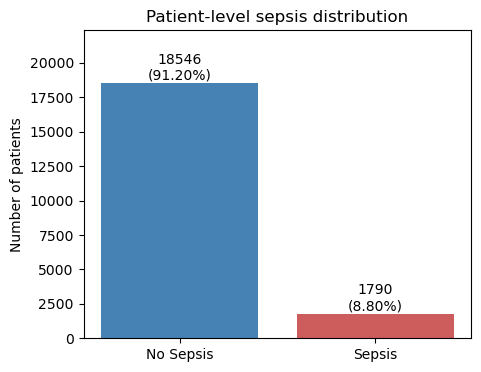

In [10]:
import matplotlib.pyplot as plt

sepsis_counts = df.groupby("PatientID")["SepsisLabel"].max().value_counts()
total_patients = sepsis_counts.sum()

plt.figure(figsize=(5, 4))
bars = plt.bar([0, 1], [sepsis_counts.get(0, 0), sepsis_counts.get(1, 0)], color=["steelblue", "indianred"])

for bar in bars:
    count = bar.get_height()
    pct = count / total_patients * 100
    plt.text(bar.get_x() + bar.get_width()/2, count, f"{int(count)}\n({pct:.2f}%)",
              ha="center", va="bottom", fontsize=10)

plt.xticks([0, 1], ["No Sepsis", "Sepsis"], rotation=0)
plt.ylabel("Number of patients")
plt.title("Patient-level sepsis distribution")
plt.ylim(0, total_patients * 1.1)
plt.show()

### Histograms of every clinical variable
Shows the distribution shape of each variable — useful for spotting skew before we later bin these variables for the Bayesian Network.

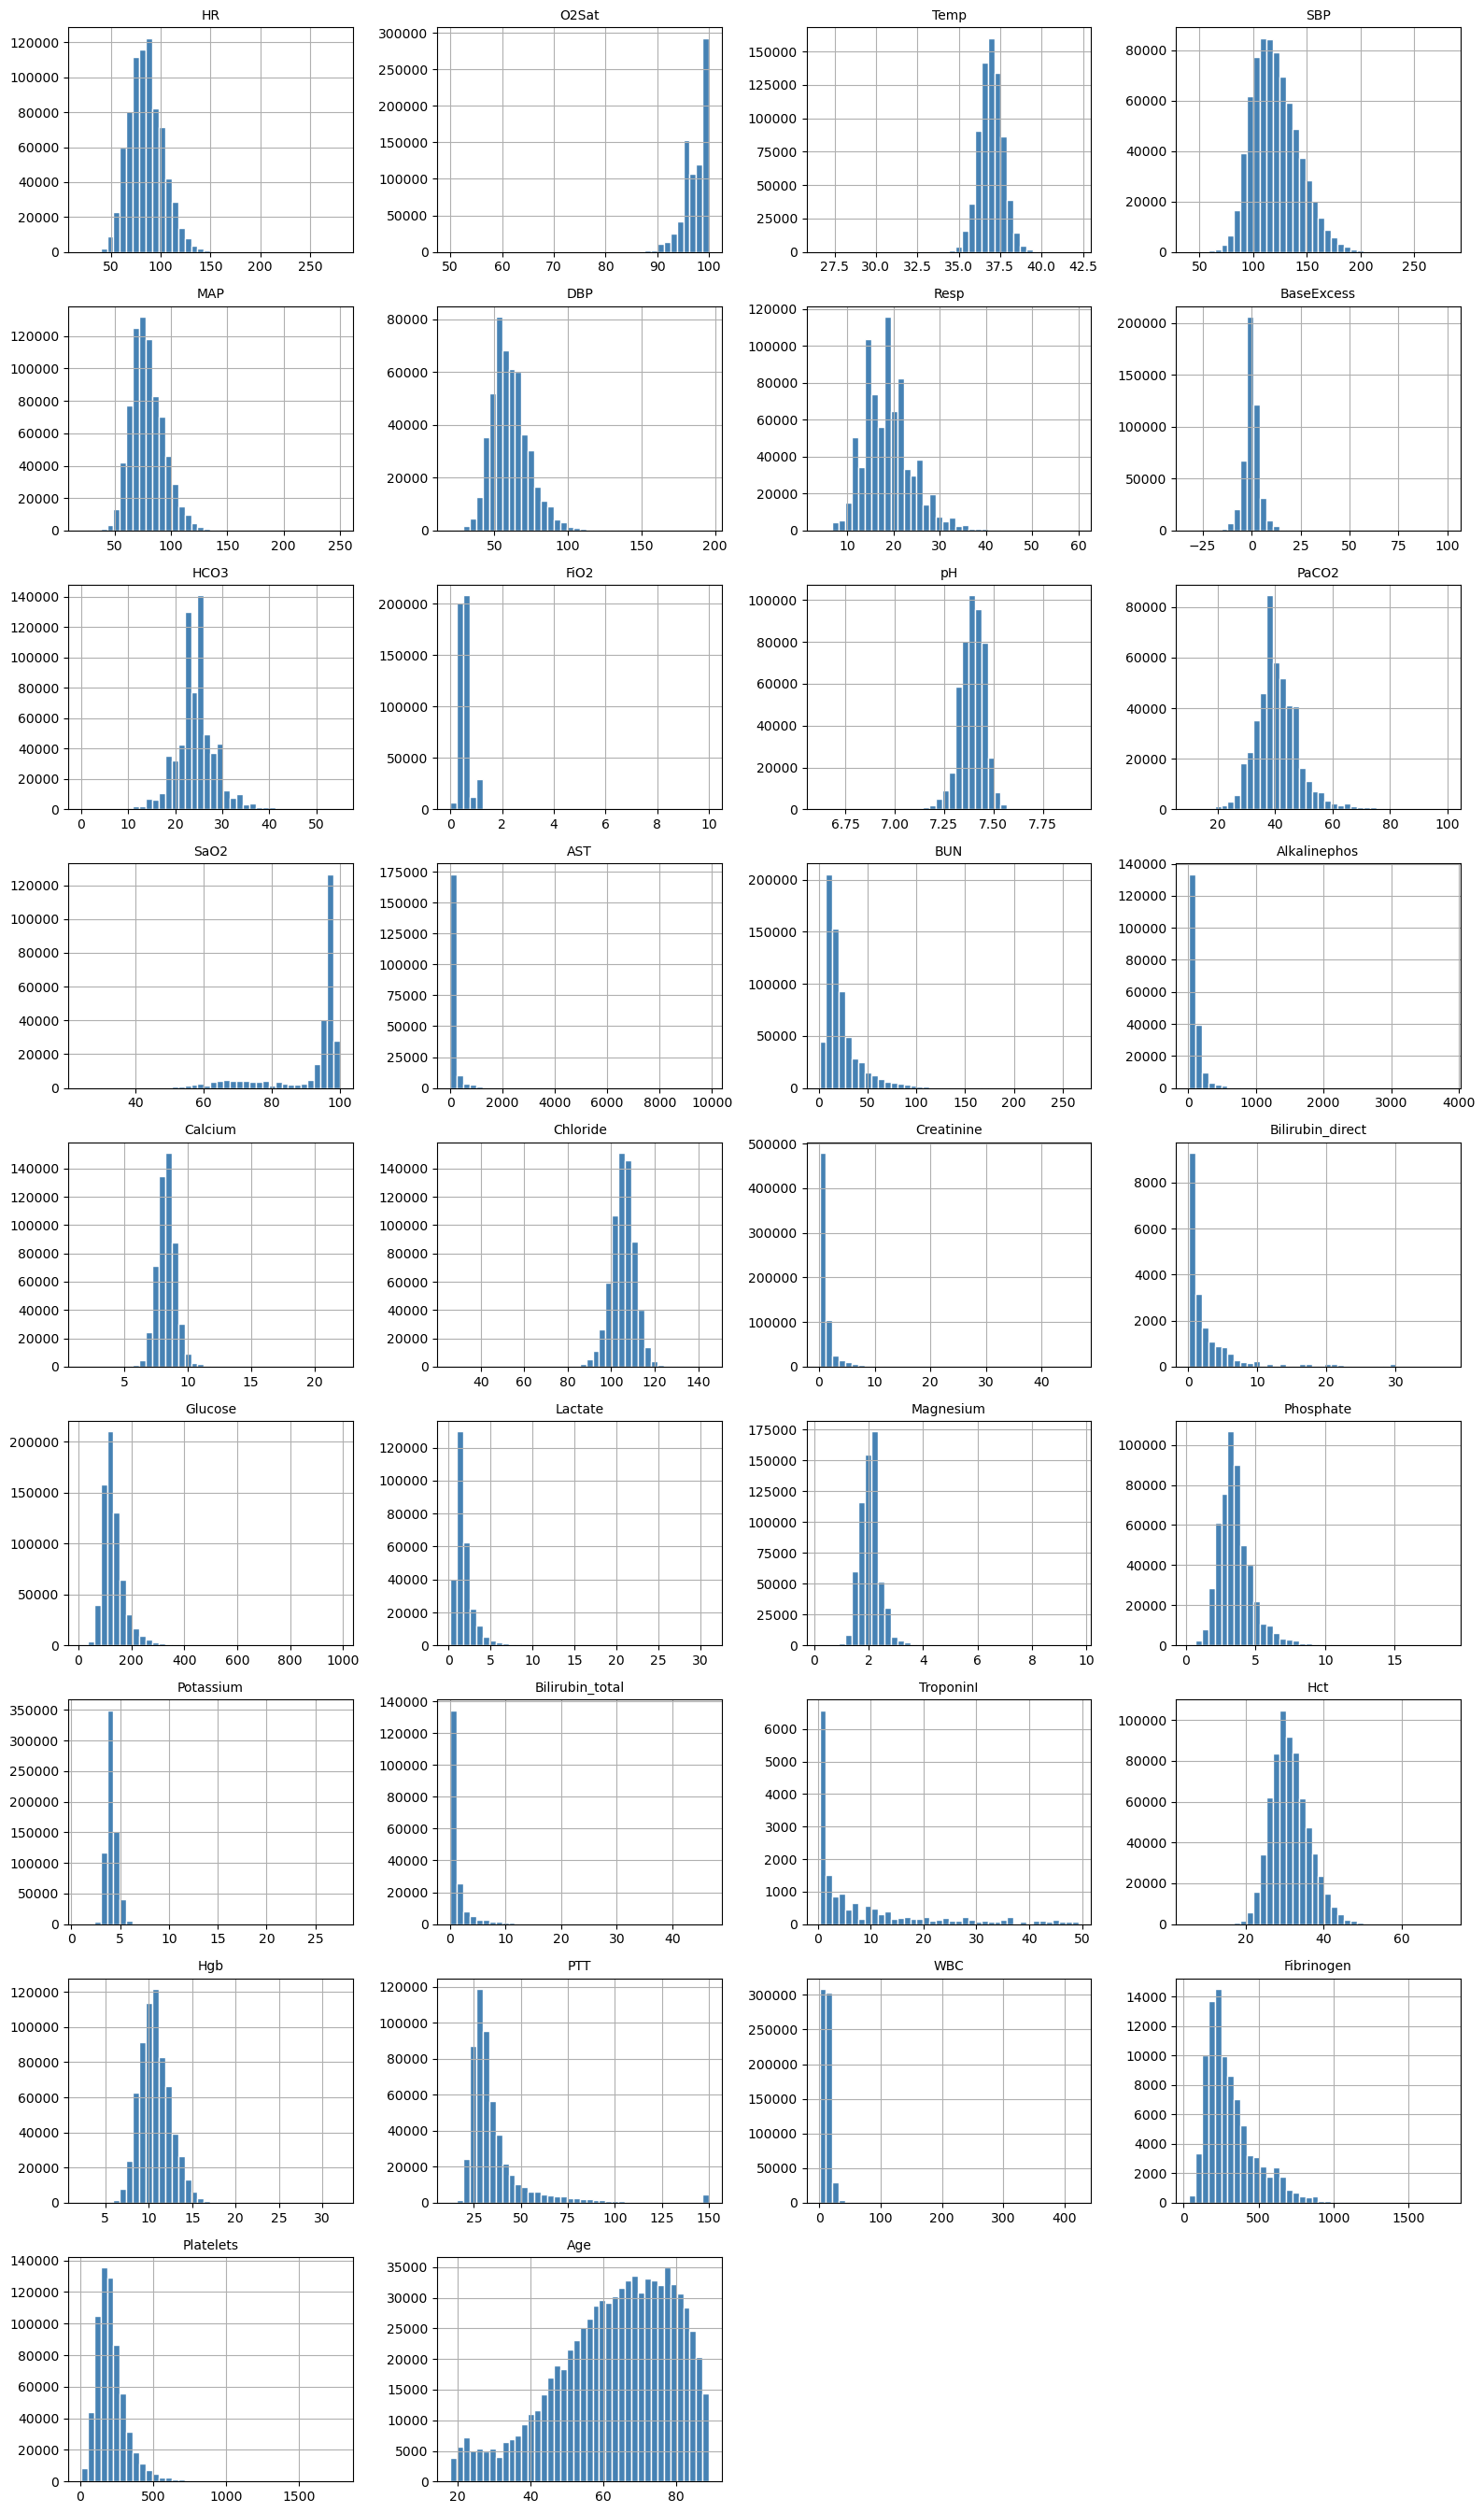

In [11]:
n_cols = 4
n_rows = -(-len(clinical_vars) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()
for ax, c in zip(axes, clinical_vars):
    df[c].hist(bins=40, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(c, fontsize=10)
for ax in axes[len(clinical_vars):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Standardized boxplots
Compares the spread and outliers of every variable side-by-side on the same scale (standardized), useful for spotting variables with extreme outliers.

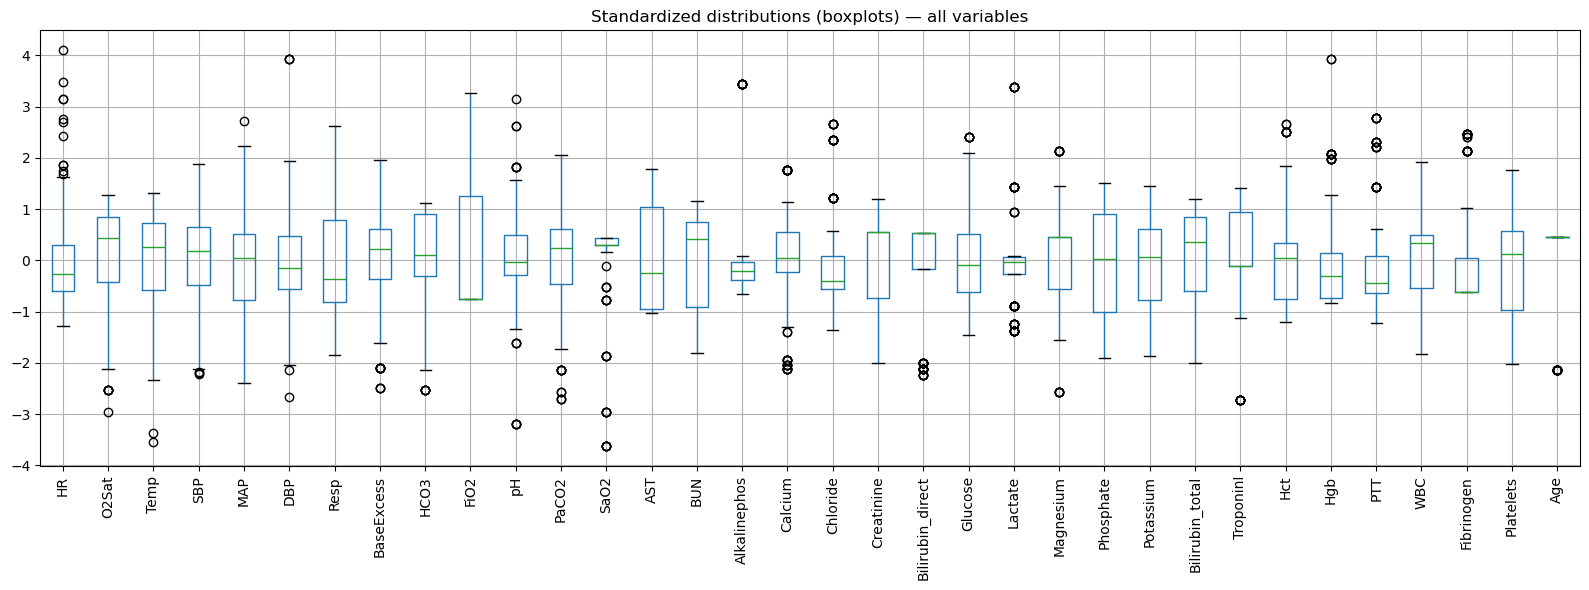

In [12]:
from sklearn.preprocessing import StandardScaler
scaled = pd.DataFrame(StandardScaler().fit_transform(df[clinical_vars].dropna()), columns=clinical_vars)

plt.figure(figsize=(16, 6))
scaled.boxplot(rot=90)
plt.title("Standardized distributions (boxplots) — all variables")
plt.tight_layout()
plt.show()

### Mean-by-class comparison & correlation heatmap
Compares each variable's average value between sepsis and non-sepsis patients (sorted by biggest difference), then shows a full correlation heatmap across all variables and the target — a first, non-predictive look at which variables might matter.

                   No Sepsis      Sepsis  difference
Fibrinogen        309.008628  362.536424   53.527796
AST               190.706627  170.781314  -19.925313
Platelets         211.050089  218.886802    7.836713
HR                 84.767273   90.348383    5.581110
BUN                23.476658   28.431476    4.954818
Glucose           132.128874  136.156573    4.027698
Alkalinephos      108.362704  106.187889   -2.174816
Resp               18.741701   20.750693    2.008992
TroponinI           8.839569    7.157364   -1.682205
PTT                36.384344   37.382431    0.998086
WBC                11.884375   12.877818    0.993443
Bilirubin_direct    2.960179    3.938641    0.978463
SaO2               91.159420   91.844582    0.685162
Hct                31.438621   30.790473   -0.648148
SBP               120.886478  120.318196   -0.568282
BaseExcess         -0.032260    0.529913    0.562174
MAP                78.860179   78.339279   -0.520901
DBP                60.602233   61.046015    0.

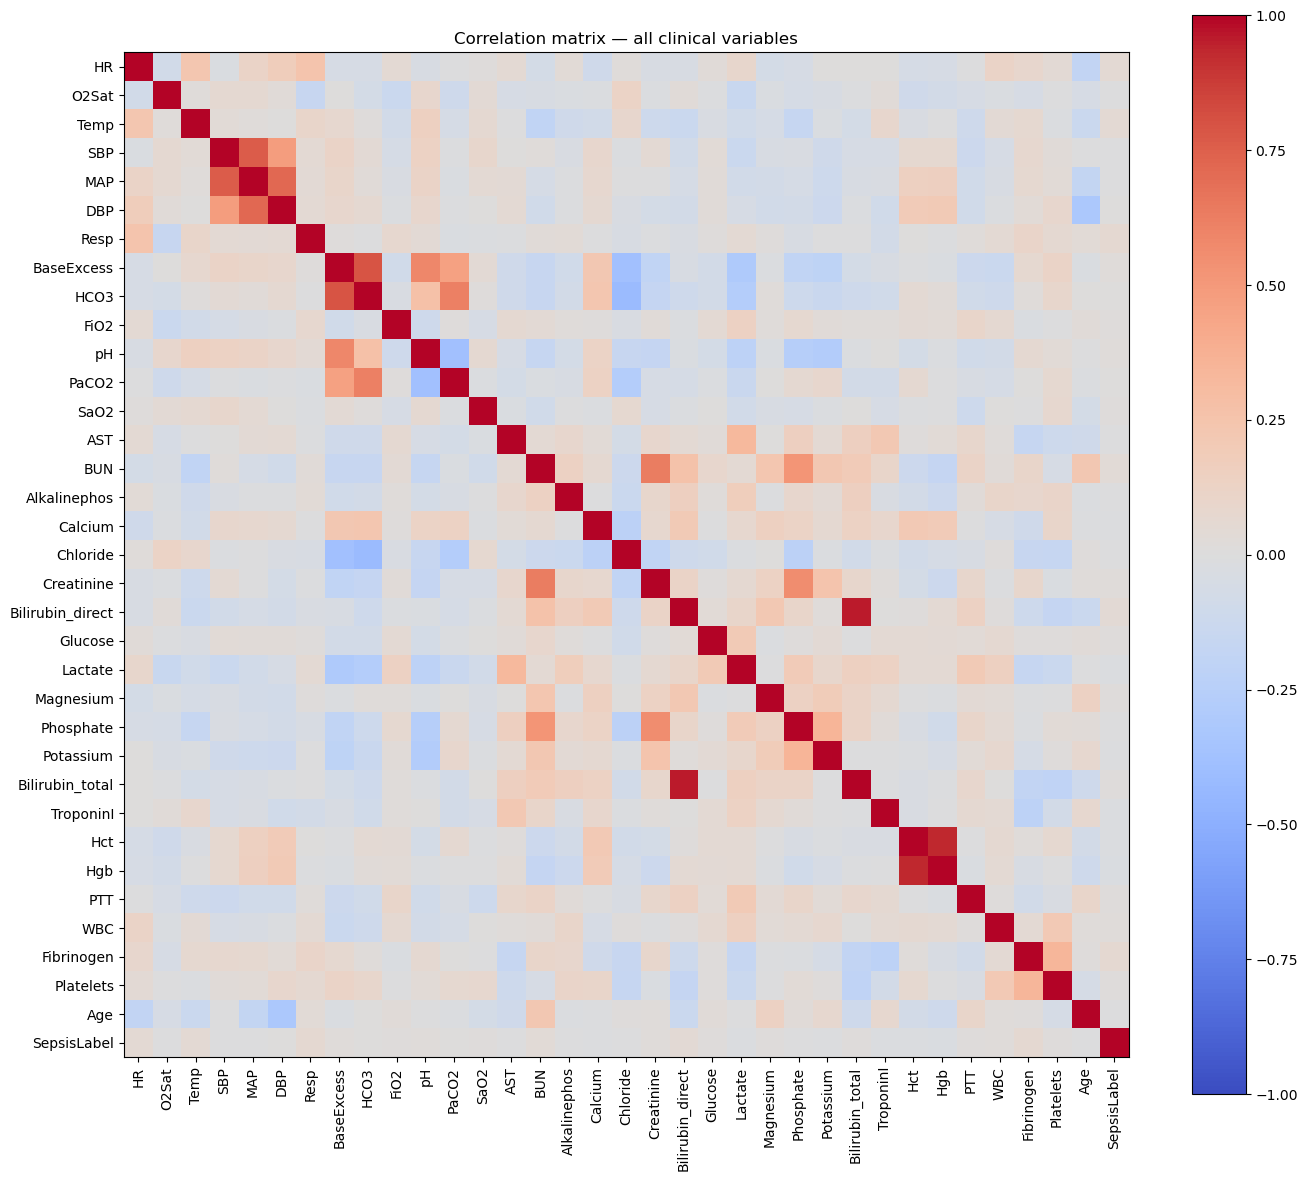

In [13]:
summary_by_class = df.groupby("SepsisLabel")[clinical_vars].mean().T
summary_by_class.columns = ["No Sepsis", "Sepsis"]
summary_by_class["difference"] = summary_by_class["Sepsis"] - summary_by_class["No Sepsis"]
print(summary_by_class.sort_values("difference", key=abs, ascending=False))

corr = df[clinical_vars + ["SepsisLabel"]].corr()
plt.figure(figsize=(14, 12))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Correlation matrix — all clinical variables")
plt.tight_layout()
plt.show()

# 4. Feature Engineering (+ more EDA!)

### Create trend features
For each of the 10 key clinical variables, adds a first-difference (change from the previous hour) and a rolling 6-hour mean — giving the model a sense of whether a patient is deteriorating, not just their current reading. Only past/current hours are used, so no future information leaks in.

In [14]:
key_vars = [c for c in ["HR","O2Sat","Temp","SBP","MAP","DBP","Resp","Lactate","WBC","Creatinine"] if c in df.columns]

df = df.sort_values(["PatientID", "ICULOS"])
for c in key_vars:
    df[f"{c}_delta"] = df.groupby("PatientID")[c].diff().fillna(0)
    df[f"{c}_roll6"] = df.groupby("PatientID")[c].transform(lambda s: s.rolling(6, min_periods=1).mean())

print(df.shape)

(790215, 61)


# 5. Data Splitting

### Split patients into train / validation / test (70/15/15)
Splits by PATIENT (not by row), stratified on patient-level sepsis outcome, so that no patient's hours appear in more than one set — this is what actually prevents leakage between train and test.

In [15]:
from sklearn.model_selection import train_test_split

patient_labels = df.groupby("PatientID")["SepsisLabel"].max()

# Step 1: split off the test set (15%)
train_val_ids, test_ids = train_test_split(
    patient_labels.index, test_size=0.15, stratify=patient_labels, random_state=42)

# Step 2: split the remaining 85% into train (70% of total) and val (15% of total)
train_val_labels = patient_labels.loc[train_val_ids]
train_ids, val_ids = train_test_split(
    train_val_ids, test_size=0.15/0.85, stratify=train_val_labels, random_state=42)

train_hourly = df[df["PatientID"].isin(train_ids)].copy()
val_hourly = df[df["PatientID"].isin(val_ids)].copy()
test_hourly = df[df["PatientID"].isin(test_ids)].copy()

print("Train:", train_hourly.shape, "Val:", val_hourly.shape, "Test:", test_hourly.shape)
print(f"Patients — train: {len(train_ids)}, val: {len(val_ids)}, test: {len(test_ids)}")

Train: (553696, 61) Val: (117616, 61) Test: (118903, 61)
Patients — train: 14234, val: 3051, test: 3051


### Fill Remaining Gaps Using the Training Set's Median

Any values still missing at this point are patients who never had that variable measured at all during their stay. The median is calculated from the training set only, then applied to fill gaps in train, validation, and test alike — the same leakage-avoidance principle already used for discretization bin edges, ensuring no information from validation/test patients influences what gets filled into the training data.

In [16]:
train_medians = train_hourly.median(numeric_only=True)

train_hourly = train_hourly.fillna(train_medians)
val_hourly = val_hourly.fillna(train_medians)
test_hourly = test_hourly.fillna(train_medians)

print("Remaining missing values —",
      f"train: {train_hourly.isna().sum().sum()},",
      f"val: {val_hourly.isna().sum().sum()},",
      f"test: {test_hourly.isna().sum().sum()}")

Remaining missing values — train: 0, val: 0, test: 0


# 6. Preprocessing & Normalisation

### Discretize features into bins
Our Bayesian Network needs categorical states, not raw numbers, so every feature is split into 4 bins. Bin edges are calculated using the TRAINING set only, then applied unchanged to validation and test — fitting only on training data is what prevents information about val/test from leaking into preprocessing.

In [17]:
feature_cols = key_vars + [f"{c}_delta" for c in key_vars] + [f"{c}_roll6" for c in key_vars]
N_BINS = 4
bin_edges = {}

train_disc = pd.DataFrame(index=train_hourly.index)
val_disc = pd.DataFrame(index=val_hourly.index)
test_disc = pd.DataFrame(index=test_hourly.index)

for c in feature_cols:
    try:
        _, edges = pd.qcut(train_hourly[c], q=N_BINS, retbins=True, duplicates="drop")
    except ValueError:
        _, edges = pd.cut(train_hourly[c], bins=N_BINS, retbins=True)
    bin_edges[c] = edges

    train_disc[c] = pd.cut(train_hourly[c], bins=edges, include_lowest=True, labels=False)
    val_disc[c] = pd.cut(val_hourly[c], bins=edges, include_lowest=True, labels=False)
    test_disc[c] = pd.cut(test_hourly[c], bins=edges, include_lowest=True, labels=False)

    train_disc[c] = train_disc[c].astype(int)
    val_disc[c] = val_disc[c].fillna(train_disc[c].median()).astype(int)
    test_disc[c] = test_disc[c].fillna(train_disc[c].median()).astype(int)

train_bn = train_disc.copy()
train_bn["SepsisLabel"] = train_hourly["SepsisLabel"].values
val_bn = val_disc.copy()
val_bn["SepsisLabel"] = val_hourly["SepsisLabel"].values
test_bn = test_disc.copy()
test_bn["SepsisLabel"] = test_hourly["SepsisLabel"].values

print(f"Train: {train_bn.shape}, Val: {val_bn.shape}, Test: {test_bn.shape}")

Train: (553696, 31), Val: (117616, 31), Test: (118903, 31)


## Discretization Bin Edges

Each continuous vital sign, lab value, delta (hour-to-hour change), and 6-hour 
rolling average was split into 4 quartile bins (labeled 0–3) before being fed 
into the Bayesian network, since `pgmpy` only supports discrete variables.

The bin boundaries below were computed from the **training set only** 
(`train_hourly`), using `pd.qcut` where possible (or `pd.cut` as a fallback when 
a column had too many repeated values to form clean quartiles — this is common 
for the `_delta` columns, where most values are 0 or near-0, resulting in fewer 
than 4 usable bins).

For each variable, bin `0` represents the lowest range of observed values in the 
training data and the highest-numbered bin represents the highest range — these 
are **data-driven quartile cutoffs specific to this dataset**, not fixed 
clinical thresholds. Use this table to interpret the `0/1/2/3` labels shown in 
the Bayesian network diagram (e.g., "WBC: 3" means WBC fell in the top quartile 
of values seen in training).

In [18]:
for c, edges in bin_edges.items():
    print(f"\n{c}:")
    for i in range(len(edges) - 1):
        print(f"  {i}: {edges[i]:.2f} to {edges[i+1]:.2f}")


HR:
  0: 20.00 to 73.00
  1: 73.00 to 84.00
  2: 84.00 to 95.00
  3: 95.00 to 223.00

O2Sat:
  0: 50.00 to 96.00
  1: 96.00 to 98.00
  2: 98.00 to 99.00
  3: 99.00 to 100.00

Temp:
  0: 26.60 to 36.50
  1: 36.50 to 36.94
  2: 36.94 to 37.39
  3: 37.39 to 41.60

SBP:
  0: 40.00 to 106.00
  1: 106.00 to 118.00
  2: 118.00 to 133.00
  3: 133.00 to 281.00

MAP:
  0: 20.00 to 69.00
  1: 69.00 to 77.00
  2: 77.00 to 87.00
  3: 87.00 to 250.00

DBP:
  0: 20.00 to 56.00
  1: 56.00 to 59.00
  2: 59.00 to 62.00
  3: 62.00 to 196.00

Resp:
  0: 4.00 to 15.00
  1: 15.00 to 18.00
  2: 18.00 to 22.00
  3: 22.00 to 60.00

Lactate:
  0: 0.20 to 1.50
  1: 1.50 to 31.00

WBC:
  0: 0.10 to 8.80
  1: 8.80 to 10.90
  2: 10.90 to 13.30
  3: 13.30 to 222.80

Creatinine:
  0: 0.10 to 0.70
  1: 0.70 to 0.90
  2: 0.90 to 1.20
  3: 1.20 to 46.60

HR_delta:
  0: -132.00 to -3.00
  1: -3.00 to 0.00
  2: 0.00 to 3.00
  3: 3.00 to 169.00

O2Sat_delta:
  0: -50.00 to -1.00
  1: -1.00 to 0.00
  2: 0.00 to 1.00
  3: 1

# 7. Model Development

### Learn the network structure
Uses Hill-Climb search (scored by BIC, which penalises overly complex graphs) to learn which variables directly depend on which — this decides the shape of the Bayesian Network from the training data itself, rather than us specifying it by hand.

In [19]:
from pgmpy.estimators import HillClimbSearch, BIC
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator

hc = HillClimbSearch(train_bn)
best_structure = hc.estimate(scoring_method=BIC(train_bn))

print(f"Learned {len(best_structure.edges())} edges:")
for parent, child in best_structure.edges():
    print(f"  {parent} -> {child}")

model_bn = DiscreteBayesianNetwork(best_structure.edges())

/home/jovyan/.local/lib/python3.12/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (
/tmp/ipykernel_1021/773876754.py:5: FutureWarning: HillClimbSearch is deprecated and will be removed in v1.3.0. Please use
            pgmpy.causal_discovery.HillClimbSearch instead.
  hc = HillClimbSearch(train_bn)


  0%|          | 0/1000000 [00:00<?, ?it/s]

Learned 107 edges:
  HR -> HR_roll6
  HR -> Resp
  HR -> MAP
  HR -> HR_delta
  HR -> O2Sat
  HR -> O2Sat_delta
  HR -> O2Sat_roll6
  O2Sat -> O2Sat_roll6
  O2Sat -> O2Sat_delta
  Temp -> Temp_roll6
  Temp -> Temp_delta
  Temp -> SepsisLabel
  SBP -> MAP
  SBP -> DBP
  SBP -> MAP_roll6
  MAP -> MAP_roll6
  MAP -> DBP
  MAP -> DBP_roll6
  MAP -> DBP_delta
  DBP -> DBP_roll6
  DBP -> DBP_delta
  Resp -> Resp_roll6
  Resp -> Resp_delta
  Lactate -> DBP
  Lactate -> WBC_roll6
  Lactate -> Creatinine
  Lactate -> Lactate_delta
  Lactate -> SepsisLabel
  WBC -> WBC_delta
  Creatinine -> Creatinine_roll6
  Creatinine -> Creatinine_delta
  Creatinine -> WBC
  HR_delta -> HR_roll6
  HR_delta -> SBP_delta
  HR_delta -> Temp_delta
  O2Sat_delta -> O2Sat_roll6
  O2Sat_delta -> MAP_delta
  O2Sat_delta -> Resp_delta
  O2Sat_delta -> HR_delta
  O2Sat_delta -> Resp
  O2Sat_delta -> SBP_delta
  Temp_delta -> Temp_roll6
  SBP_delta -> SBP
  SBP_delta -> DBP_delta
  SBP_delta -> DBP
  SBP_delta -> MAP
  

### Fit the model's probability tables
Given the learned structure, estimates the actual conditional probability table at every node using the training set, with a BDeu prior for smoothing (so rare/unseen combinations aren't given zero probability).

In [20]:
from pgmpy.estimators import BayesianEstimator

estimator = BayesianEstimator(model_bn, train_bn)
cpds = estimator.get_parameters(prior_type="BDeu", equivalent_sample_size=10)
model_bn.add_cpds(*cpds)

print("BN fitted. Nodes:", len(model_bn.nodes()))

/tmp/ipykernel_1021/2752928915.py:3: FutureWarning: `pgmpy.estimators.BayesianEstimator` is deprecated and will be removed in v1.3.0. Please use `pgmpy.parameter_estimator.DiscreteBayesianEstimator` instead.
  estimator = BayesianEstimator(model_bn, train_bn)


BN fitted. Nodes: 31


### Visualise the learned network
Draws SepsisLabel and everything within 2 hops of it as a diagram, with each node showing its own probability distribution as mini bars — the full 31-node graph is too dense to read, so this focuses on the part that matters most.

Showing 17 of 31 nodes (within 2 hops of SepsisLabel)


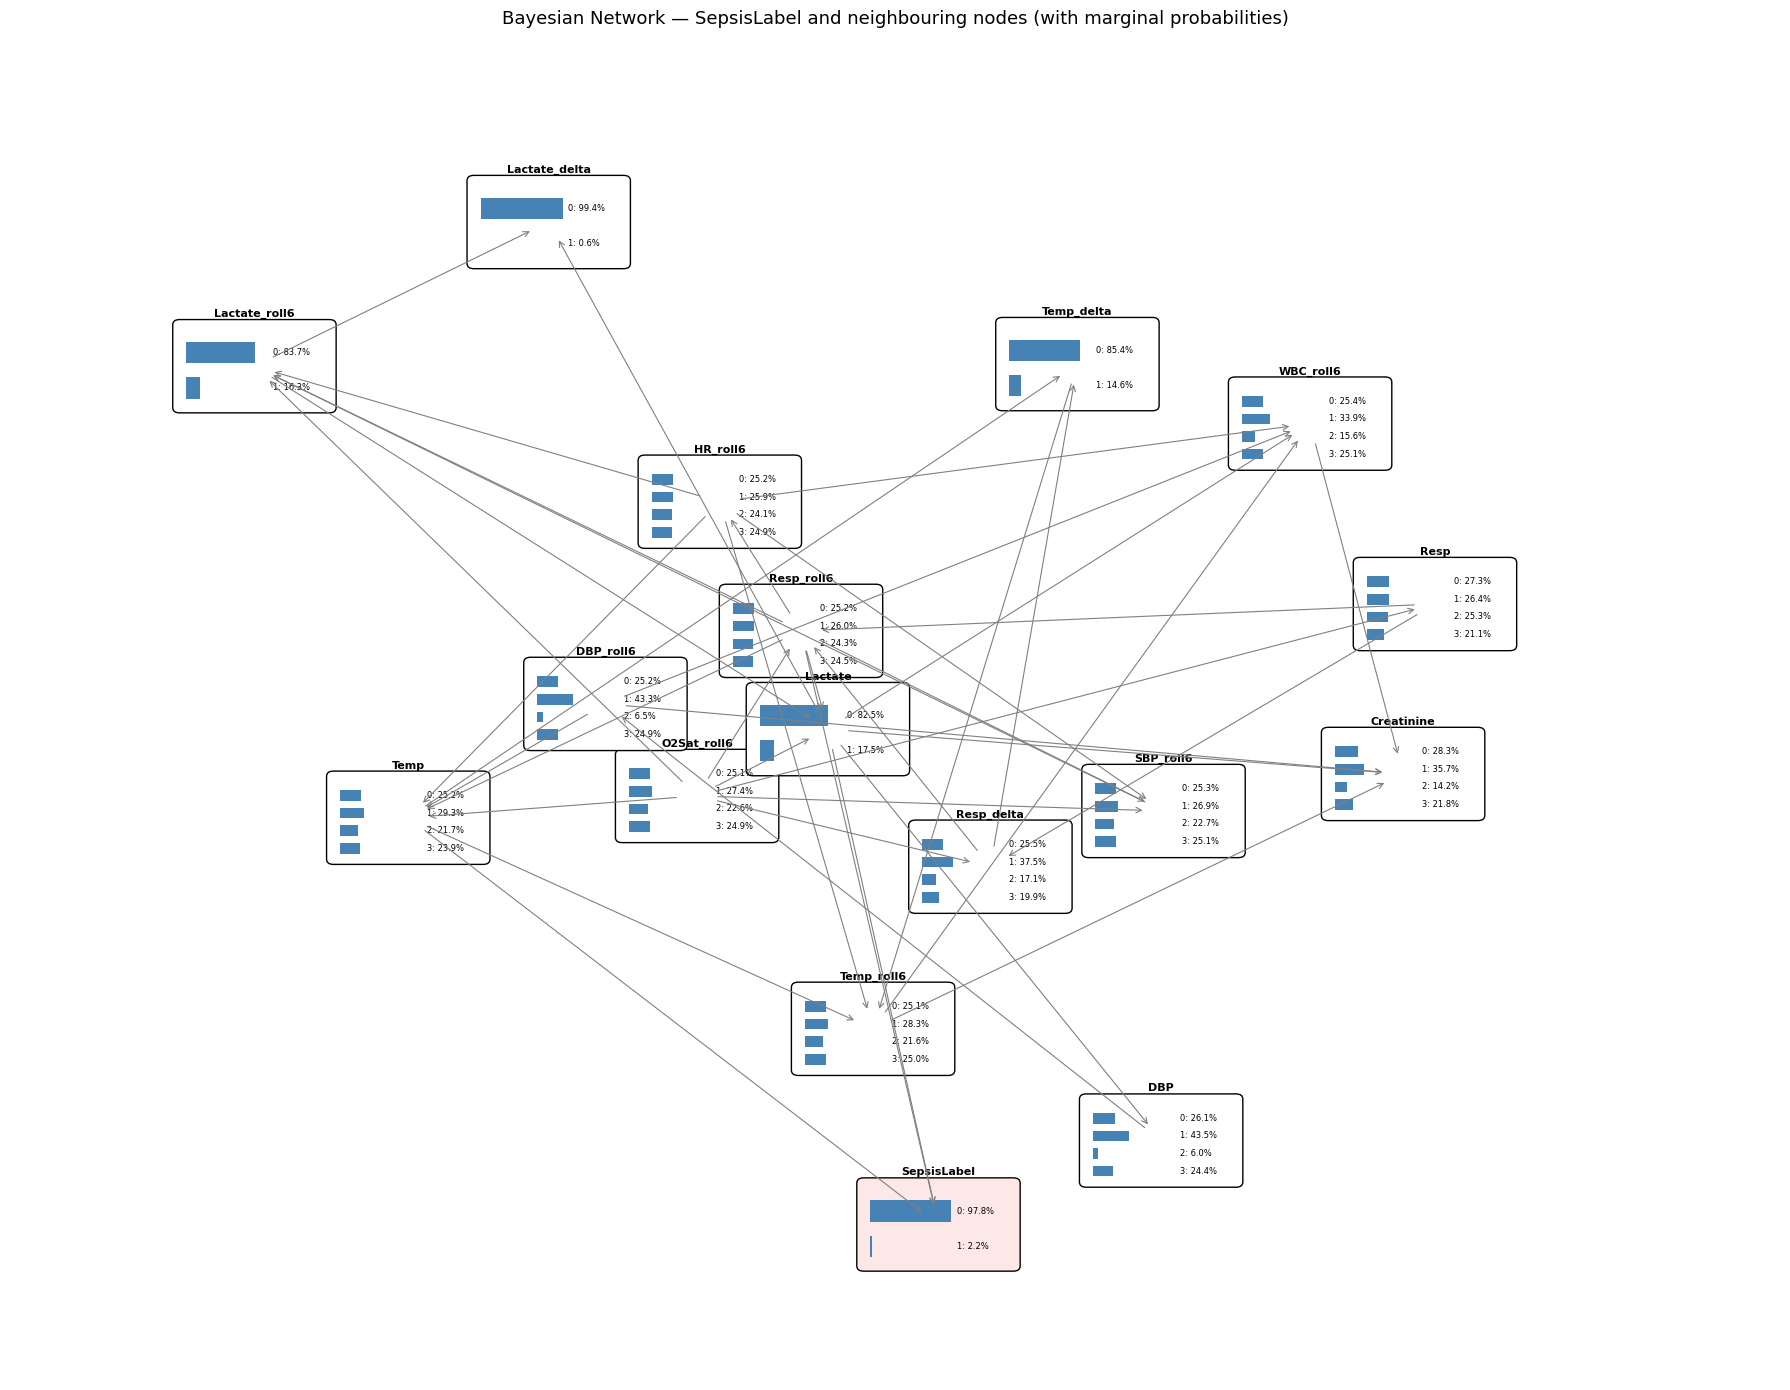

In [21]:
from pgmpy.inference import VariableElimination
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import networkx as nx
import numpy as np

G_full = nx.DiGraph()
G_full.add_edges_from(model_bn.edges())
G_undirected = G_full.to_undirected()
nearby = nx.single_source_shortest_path_length(G_undirected, "SepsisLabel", cutoff=2)
subgraph_nodes = list(nearby.keys())
G_sub = G_full.subgraph(subgraph_nodes)
print(f"Showing {len(subgraph_nodes)} of {len(G_full.nodes())} nodes (within 2 hops of SepsisLabel)")

infer_marginal = VariableElimination(model_bn)
node_probs = {}
node_states = {}  # NEW: store the state labels for each node
for node in subgraph_nodes:
    result = infer_marginal.query(variables=[node], show_progress=False)
    node_probs[node] = result.values
    node_states[node] = result.state_names[node]  # NEW: e.g. [0, 1] or ["No", "Yes"]

pos = nx.spring_layout(G_sub, seed=42, k=1.5)
fig, ax = plt.subplots(figsize=(18, 14))
box_w, box_h = 0.22, 0.16

for node, (x, y) in pos.items():
    probs = node_probs[node]
    states = node_states[node]  # NEW
    n_states = len(probs)
    is_target = node == "SepsisLabel"
    rect = patches.FancyBboxPatch((x - box_w/2, y - box_h/2), box_w, box_h,
                                    boxstyle="round,pad=0.01", linewidth=1, edgecolor="black",
                                    facecolor="#fde8e8" if is_target else "white")
    ax.add_patch(rect)
    ax.text(x, y + box_h/2 + 0.015, node, ha="center", fontsize=8, fontweight="bold")
    bar_area_h = box_h * 0.85
    row_h = bar_area_h / n_states
    for i, p in enumerate(probs):
        row_y = y + box_h/2 - 0.02 - (i + 0.5) * row_h
        bar_len = p * box_w * 0.55
        ax.add_patch(patches.Rectangle((x - box_w/2 + 0.01, row_y - row_h*0.3),
                                        bar_len, row_h*0.6, facecolor="steelblue", edgecolor="none"))
        # NEW: prefix the percentage with the state label, e.g. "0: 97.8%"
        label = f"{states[i]}: {p:.1%}"
        ax.text(x - box_w/2 + 0.01 + box_w*0.58, row_y, label, fontsize=6, va="center")

for u, v in G_sub.edges():
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color="gray", lw=0.8, shrinkA=15, shrinkB=15))

ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.axis("off")
ax.set_title("Bayesian Network — SepsisLabel and neighbouring nodes (with marginal probabilities)", fontsize=13)
plt.tight_layout()
plt.show()

### Inspect SepsisLabel's probability table
Prints the fitted conditional probability table for SepsisLabel specifically (the one table that actually matters for prediction), rather than all 31 tables in the network.

In [22]:
print(model_bn.get_cpds("SepsisLabel"))

+----------------+-----+----------------------+
| Lactate        | ... | Lactate(1)           |
+----------------+-----+----------------------+
| Resp_roll6     | ... | Resp_roll6(3)        |
+----------------+-----+----------------------+
| Temp           | ... | Temp(3)              |
+----------------+-----+----------------------+
| SepsisLabel(0) | ... | 0.9431312017640573   |
+----------------+-----+----------------------+
| SepsisLabel(1) | ... | 0.056868798235942666 |
+----------------+-----+----------------------+


### Generate predictions on train/val/test
Computes P(SepsisLabel=1 | evidence) for every hourly record. SPEED-UP: since every feature is just a 0-3 bin, many rows share the exact same combination of bins — so instead of asking the model the same question thousands of times, we compute each unique combination once and map the answer back to every matching row.

In [23]:
from pgmpy.inference import VariableElimination

infer = VariableElimination(model_bn)
evidence_cols = [c for c in feature_cols if c in model_bn.nodes()]

def predict_proba_row(row):
    evidence = {c: int(row[c]) for c in evidence_cols}
    try:
        result = infer.query(variables=["SepsisLabel"], evidence=evidence, show_progress=False)
        return result.values[1]
    except Exception:
        return np.nan

def compute_proba_fast(data_bn):
    """Computes probabilities once per UNIQUE combination of feature bins, then maps
    the result back to every row sharing that combination — much faster than querying
    the network once per row when many rows repeat the same evidence."""
    unique_combos = data_bn[evidence_cols].drop_duplicates().copy()
    unique_combos["proba"] = unique_combos.apply(predict_proba_row, axis=1)
    merged = data_bn[evidence_cols].merge(unique_combos, on=evidence_cols, how="left")
    return merged["proba"].values

y_proba = compute_proba_fast(test_bn)
y_proba = pd.Series(y_proba, index=test_bn.index)
y_proba = y_proba.fillna(y_proba.mean())

print(y_proba.describe())

count    118903.000000
mean          0.021579
std           0.012008
min           0.009759
25%           0.011865
50%           0.018763
75%           0.027325
max           0.056869
dtype: float64


# 8. Model Validation & Selection

### Baseline metrics at the default 0.5 threshold
Computes precision, recall, F1, ROC-AUC, PR-AUC, log-loss, and Brier score at the standard 0.5 cutoff — this deliberately fails (near-zero precision/recall) because sepsis is rare and predicted probabilities are almost always below 0.5, which is exactly why a better threshold is needed next.

In [24]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix,
    roc_auc_score, average_precision_score, roc_curve,
    log_loss, brier_score_loss, classification_report)

y_test = test_bn["SepsisLabel"]
THRESHOLD = 0.5
y_pred = (y_proba >= THRESHOLD).astype(int)

print(classification_report(y_test, y_pred, digits=3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1:", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print("PR-AUC:", round(average_precision_score(y_test, y_proba), 3))
print("Log-loss:", round(log_loss(y_test, y_proba), 3))
print("Brier score:", round(brier_score_loss(y_test, y_proba), 3))

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
specificity = 1 - fpr
idx = np.argmin(np.abs(specificity - 0.85))
print(f"Sensitivity at ~{specificity[idx]:.2%} specificity: {tpr[idx]:.3f} (threshold={thresholds[idx]:.3f})")

              precision    recall  f1-score   support

           0      0.978     1.000     0.989    116326
           1      0.000     0.000     0.000      2577

    accuracy                          0.978    118903
   macro avg      0.489     0.500     0.495    118903
weighted avg      0.957     0.978     0.968    118903

Precision: 0.0
Recall: 0.0
F1: 0.0
ROC-AUC: 0.646
PR-AUC: 0.037
Log-loss: 0.102
Brier score: 0.021
Sensitivity at ~86.24% specificity: 0.286 (threshold=0.035)


/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.12/site-packag

### Threshold chosen on the TEST set — a leakage mistake, kept to show the fix
An earlier version of this analysis picked a threshold by searching the TEST set's own ROC curve. This is a genuine methodological error: it uses the same data reserved for final reporting to make a design decision (data leakage). We keep the metrics here to document the mistake; the corrected version — which fixes this by using the validation set instead — is in the next cell, and its single confusion matrix is the one we report as final.

In [25]:
BETTER_THRESHOLD_LEAKY = thresholds[idx]  # threshold found from the TEST set's own ROC curve — LEAKY, see note above
y_pred_adjusted = (y_proba >= BETTER_THRESHOLD_LEAKY).astype(int)

print(classification_report(y_test, y_pred_adjusted, digits=3))
print("Precision:", round(precision_score(y_test, y_pred_adjusted), 3))
print("Recall:", round(recall_score(y_test, y_pred_adjusted), 3))
print("F1:", round(f1_score(y_test, y_pred_adjusted), 3))
# NOTE: no confusion matrix plotted here on purpose — we only plot ONE confusion matrix,
# for the corrected (validation-based) threshold, in the next cell.

              precision    recall  f1-score   support

           0      0.982     0.862     0.918    116326
           1      0.044     0.286     0.076      2577

    accuracy                          0.850    118903
   macro avg      0.513     0.574     0.497    118903
weighted avg      0.962     0.850     0.900    118903

Precision: 0.044
Recall: 0.286
F1: 0.076


### Threshold fixed using the VALIDATION set — this is our final result
Corrects the leakage above: the probability estimates and threshold search are done entirely on the validation set, and only afterwards applied ONCE to the already-computed test-set predictions. This is the single confusion matrix we report.

Threshold chosen on validation set: 0.035
Validation sensitivity at this threshold: 0.287 (specificity: 86.06%)
              precision    recall  f1-score   support

           0      0.982     0.862     0.918    116326
           1      0.044     0.286     0.076      2577

    accuracy                          0.850    118903
   macro avg      0.513     0.574     0.497    118903
weighted avg      0.962     0.850     0.900    118903

Precision: 0.044
Recall: 0.286
F1: 0.076
ROC-AUC: 0.646
PR-AUC: 0.037
Final confusion matrix (threshold chosen on val, applied to test):
 [[100321  16005]
 [  1840    737]]


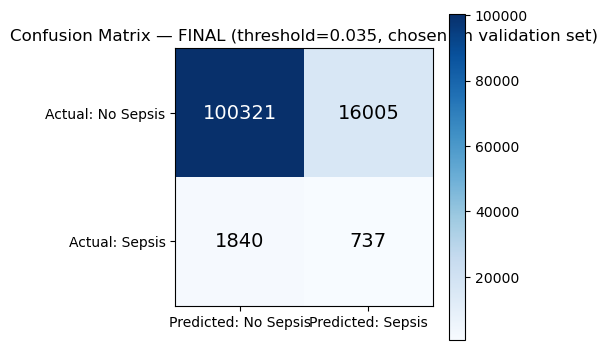

In [26]:
from sklearn.metrics import roc_curve

y_val_proba = compute_proba_fast(val_bn)
y_val_proba = pd.Series(y_val_proba, index=val_bn.index)
y_val_proba = y_val_proba.fillna(y_val_proba.mean())

y_val = val_bn["SepsisLabel"]
val_fpr, val_tpr, val_thresholds = roc_curve(y_val, y_val_proba)
val_specificity = 1 - val_fpr

val_idx = np.argmin(np.abs(val_specificity - 0.85))
BETTER_THRESHOLD = val_thresholds[val_idx]

print(f"Threshold chosen on validation set: {BETTER_THRESHOLD:.3f}")
print(f"Validation sensitivity at this threshold: {val_tpr[val_idx]:.3f} (specificity: {val_specificity[val_idx]:.2%})")

y_pred_final = (y_proba >= BETTER_THRESHOLD).astype(int)

print(classification_report(y_test, y_pred_final, digits=3))
print("Precision:", round(precision_score(y_test, y_pred_final), 3))
print("Recall:", round(recall_score(y_test, y_pred_final), 3))
print("F1:", round(f1_score(y_test, y_pred_final), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print("PR-AUC:", round(average_precision_score(y_test, y_proba), 3))

cm_final = confusion_matrix(y_test, y_pred_final)
print("Final confusion matrix (threshold chosen on val, applied to test):\n", cm_final)

plt.figure(figsize=(5,4))
plt.imshow(cm_final, cmap="Blues")
plt.colorbar()
plt.xticks([0,1], ["Predicted: No Sepsis", "Predicted: Sepsis"])
plt.yticks([0,1], ["Actual: No Sepsis", "Actual: Sepsis"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_final[i,j], ha="center", va="center",
                  color="white" if cm_final[i,j] > cm_final.max()/2 else "black", fontsize=14)
plt.title(f"Confusion Matrix — FINAL (threshold={BETTER_THRESHOLD:.3f}, chosen on validation set)")
plt.tight_layout()
plt.show()

### Validation ROC-AUC and PR-AUC (Generalisation Check)

Computes the same threshold-independent metrics used for the test set (ROC-AUC and PR-AUC) on the validation set instead. This isn't needed for threshold selection itself, but comparing these numbers against the test-set results is a useful check that the model's performance is stable across different patients, rather than the test-set numbers being a one-off result specific to that particular split.

In [27]:
val_auroc = roc_auc_score(y_val, y_val_proba)
val_auprc = average_precision_score(y_val, y_val_proba)
print(f"Validation ROC-AUC: {val_auroc:.3f}")
print(f"Validation PR-AUC: {val_auprc:.3f}")

Validation ROC-AUC: 0.625
Validation PR-AUC: 0.035


# 9. Final Evaluation of Deployable Pipeline

The plots below all use the TEST set and are threshold-independent — they assess the quality of the model's raw probability output, on top of the single confusion matrix already reported above.

### ROC curve
Plots the true/false positive rate trade-off across every possible threshold, with our chosen (validation-based) threshold marked.

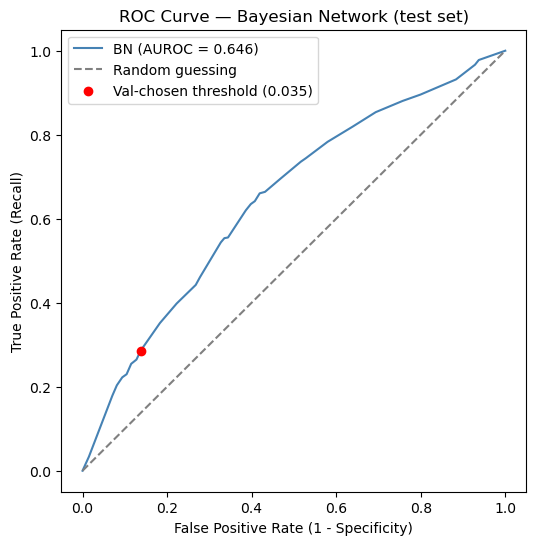

In [28]:
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"BN (AUROC = {roc_auc_score(y_test, y_proba):.3f})", color="steelblue")
plt.plot([0,1],[0,1], linestyle="--", color="gray", label="Random guessing")

mark_idx = np.argmin(np.abs(thresholds - BETTER_THRESHOLD))
plt.scatter(fpr[mark_idx], tpr[mark_idx], color="red", zorder=5,
            label=f"Val-chosen threshold ({BETTER_THRESHOLD:.3f})")

plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Bayesian Network (test set)")
plt.legend()
plt.show()

### Precision-Recall curve
More informative than ROC given how rare sepsis is — shows the trade-off between catching true cases and avoiding false alarms.

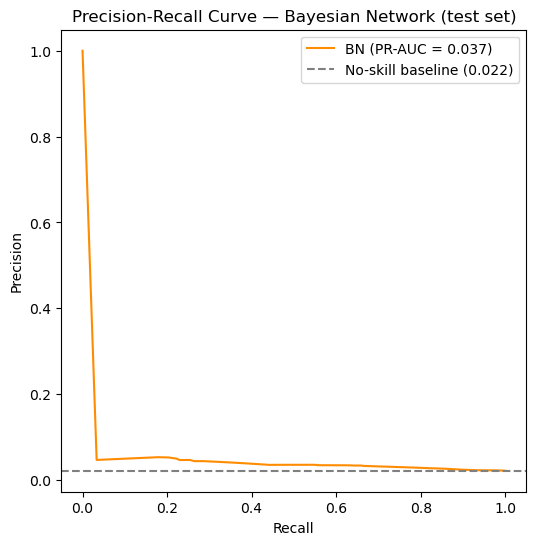

In [29]:
from sklearn.metrics import precision_recall_curve

prec, rec, pr_thresholds = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(6,6))
plt.plot(rec, prec, color="darkorange", label=f"BN (PR-AUC = {average_precision_score(y_test, y_proba):.3f})")
plt.axhline(y_test.mean(), linestyle="--", color="gray", label=f"No-skill baseline ({y_test.mean():.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Bayesian Network (test set)")
plt.legend()
plt.show()

### Predicted probability distribution by true class
Shows why the 0.5 threshold fails and why a much lower one is needed — most predictions cluster far below 0.5 regardless of true outcome, since sepsis is rare.

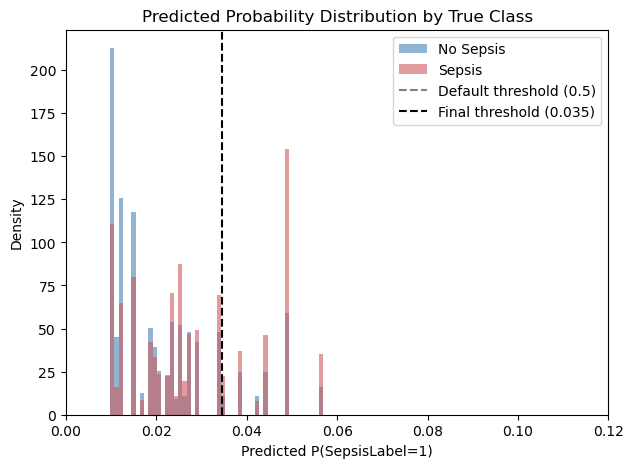

In [30]:
plt.figure(figsize=(7,5))
plt.hist(y_proba[y_test==0], bins=50, alpha=0.6, label="No Sepsis", color="steelblue", density=True)
plt.hist(y_proba[y_test==1], bins=50, alpha=0.6, label="Sepsis", color="indianred", density=True)
plt.axvline(0.5, color="gray", linestyle="--", label="Default threshold (0.5)")
plt.axvline(BETTER_THRESHOLD, color="black", linestyle="--", label=f"Final threshold ({BETTER_THRESHOLD:.3f})")
plt.xlim(0, 0.12)
plt.xlabel("Predicted P(SepsisLabel=1)")
plt.ylabel("Density")
plt.title("Predicted Probability Distribution by True Class")
plt.legend()
plt.show()

### Calibration curve
Checks whether predicted probabilities match real-world sepsis frequencies (e.g. among rows predicted ~5% risk, do ~5% actually turn out septic?) — a different question from ranking ability (ROC/PR).

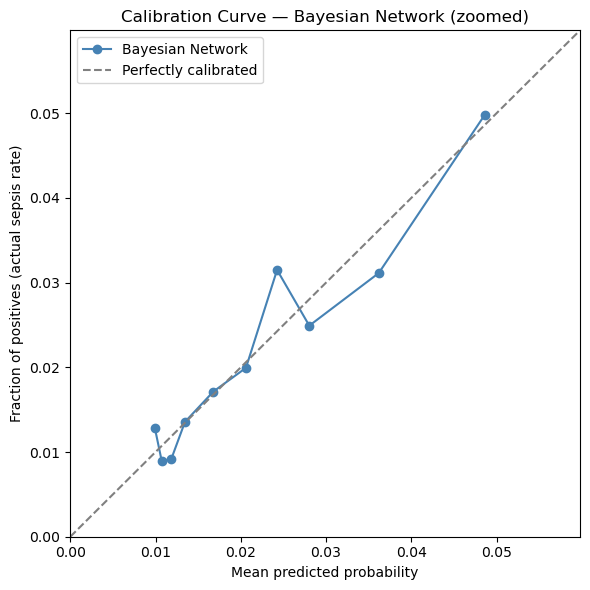

In [31]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy="quantile")

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker="o", color="steelblue", label="Bayesian Network")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")

max_val = max(prob_pred.max(), prob_true.max()) * 1.2
plt.xlim(0, max_val)
plt.ylim(0, max_val)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives (actual sepsis rate)")
plt.title("Calibration Curve — Bayesian Network (zoomed)")
plt.legend()
plt.tight_layout()
plt.show()

### Average Lead Time Before Diagnosis

Measures how many hours in advance the model flags a septic patient as high-risk, relative to when the official SepsisLabel first turns positive (which itself is set 6 hours before clinical suspicion was documented, per the PhysioNet challenge definition). For every septic patient in the test set, we find the first hour they were flagged by the model and compare it to the first hour their label turns positive — the gap between the two is that patient's lead time. We report both the average/median lead time and the percentage of septic patients caught early at all, since a high average taken from only a few caught cases can be misleading on its own.

In [32]:
# Build a results table combining patient/hour info with the model's predictions.
# test_bn shares the same row index as test_hourly, so we can align them directly.
results = test_hourly[["PatientID", "ICULOS", "SepsisLabel"]].copy()
results["y_proba"] = y_proba.values
results["y_pred"] = y_pred_final  # 0/1 flag at our chosen threshold

lead_times = []

for pid, group in results.groupby("PatientID"):
    group = group.sort_values("ICULOS")
    septic_hours = group[group["SepsisLabel"] == 1]
    if septic_hours.empty:
        continue  # this patient never had sepsis — lead time doesn't apply

    onset_hour = septic_hours["ICULOS"].iloc[0]  # first hour the official label turns 1

    # only look at hours BEFORE onset — did the model raise a flag in advance?
    pre_onset = group[group["ICULOS"] < onset_hour]
    flagged_early = pre_onset[pre_onset["y_pred"] == 1]

    if not flagged_early.empty:
        first_flag_hour = flagged_early["ICULOS"].iloc[0]
        lead_times.append(onset_hour - first_flag_hour)
    # if never flagged before onset, this patient contributes no lead time (a missed early case)

lead_times = pd.Series(lead_times)
n_septic = results[results["SepsisLabel"] == 1]["PatientID"].nunique()

print(f"Septic patients in test set: {n_septic}")
print(f"Septic patients flagged BEFORE official label onset: {len(lead_times)} ({len(lead_times)/n_septic:.1%})")
print(f"Average lead time before label onset: {lead_times.mean():.2f} hours")
print(f"Median lead time: {lead_times.median():.2f} hours")

# Since SepsisLabel is already set 6 hours before clinical suspicion (per the 2019 challenge
# definition), add that offset to estimate lead time relative to actual clinical diagnosis
CLINICAL_SUSPICION_OFFSET = 6
lead_times_vs_diagnosis = lead_times + CLINICAL_SUSPICION_OFFSET
print(f"Average lead time before ESTIMATED clinical diagnosis: {lead_times_vs_diagnosis.mean():.2f} hours")

Septic patients in test set: 269
Septic patients flagged BEFORE official label onset: 126 (46.8%)
Average lead time before label onset: 57.59 hours
Median lead time: 37.50 hours
Average lead time before ESTIMATED clinical diagnosis: 63.59 hours


### Visualising Lead Time Distribution

Plots the spread of lead times across all septic patients the model successfully flagged before official onset, with the average marked — shows not just the typical lead time but how consistent it is across patients (a tight cluster around the mean vs. a wide spread with a few large outliers tell very different stories about reliability).

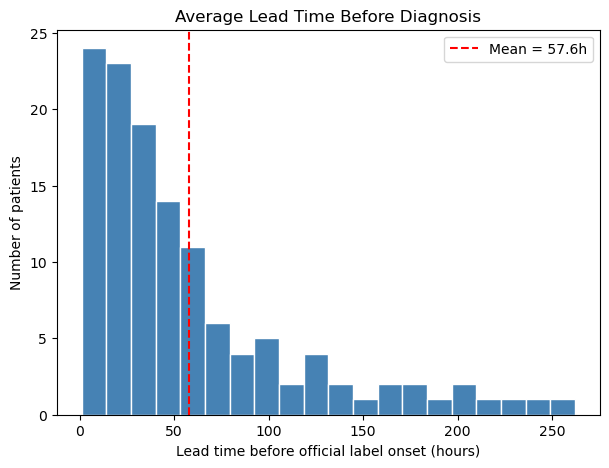

In [33]:
plt.figure(figsize=(7,5))
plt.hist(lead_times, bins=20, color="steelblue", edgecolor="white")
plt.axvline(lead_times.mean(), color="red", linestyle="--", label=f"Mean = {lead_times.mean():.1f}h")
plt.xlabel("Lead time before official label onset (hours)")
plt.ylabel("Number of patients")
plt.title("Average Lead Time Before Diagnosis")
plt.legend()
plt.show()

### Environment fix for SHAP (only needed if the SHAP cell below errors)
SHAP depends on numba, which can conflict with newer NumPy versions on some Jupyter setups. Run this ONLY if the SHAP cell below throws a NumPy/numba version error — then restart the kernel and re-run the notebook from the top before trying SHAP again.

In [34]:
import sys
!{sys.executable} -m pip uninstall numpy -y
!{sys.executable} -m pip install "numpy==2.4.1" --no-cache-dir --force-reinstall
# After this finishes: Kernel -> Restart Kernel, then re-run the notebook from the top.

Found existing installation: numpy 2.4.1
Uninstalling numpy-2.4.1:
  Successfully uninstalled numpy-2.4.1
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 173.2 MB/s  0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlend 1.0.0.4 requires numpy<2.0, but you have numpy 2.4.1 which is incompatible.


### Check environment (only needed for troubleshooting)
If NumPy/numba errors persist after the fix above, this prints your Python path so we can see exactly which environment is being used.

In [35]:
import sys
for p in sys.path:
    print(p)

/usr/local/etc/jupyter
/opt/conda/lib/python312.zip
/opt/conda/lib/python3.12
/opt/conda/lib/python3.12/lib-dynload

/home/jovyan/.local/lib/python3.12/site-packages
/opt/conda/lib/python3.12/site-packages


### SHAP — explain individual predictions
SHAP shows how much each feature pushed a specific prediction up or down, which is a useful cross-check against the network structure above. Kept to a small sample since each SHAP call means another real Bayesian Network query.

  0%|          | 0/50 [00:00<?, ?it/s]

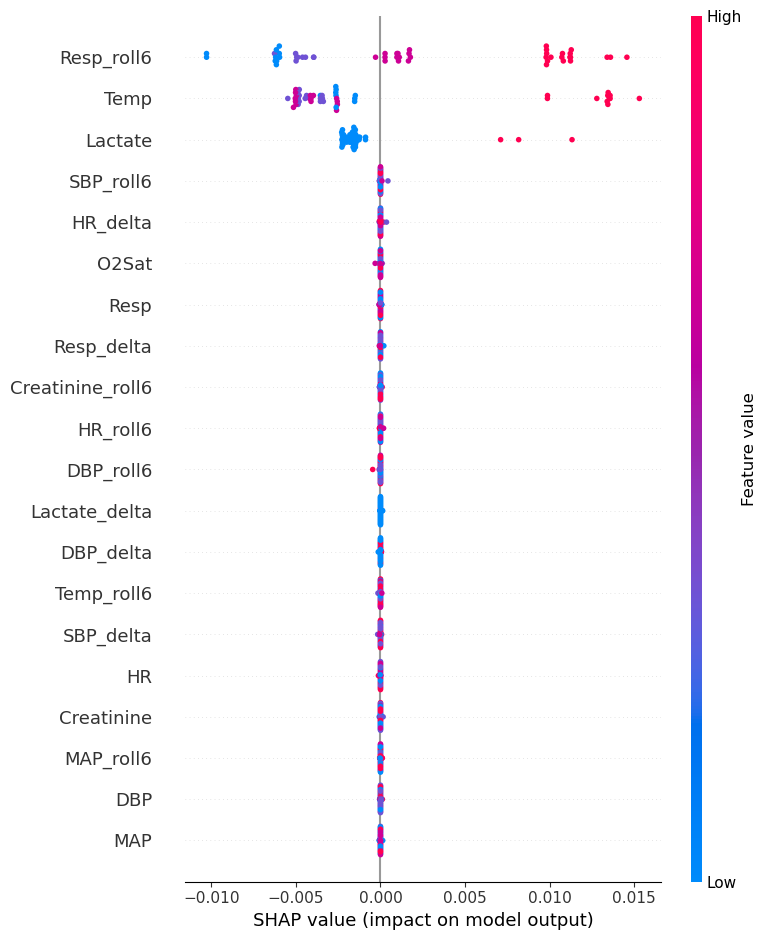

In [36]:
import shap

background = train_bn[evidence_cols].sample(100, random_state=42).values
explain_sample = test_bn[evidence_cols].sample(50, random_state=42)

def bn_predict(X):
    X_df = pd.DataFrame(X, columns=evidence_cols).astype(int)
    return X_df.apply(lambda row: predict_proba_row(row), axis=1).values

explainer = shap.KernelExplainer(bn_predict, background)
shap_values = explainer.shap_values(explain_sample.values, nsamples=100)

shap.summary_plot(shap_values, explain_sample, feature_names=evidence_cols)